In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.20014286128198325, max_depth=5, n_estimators=171, reg_alpha=0.5986584841970366, reg_lambda=0.15601864044243652, subsample=0.662397808134481; total time=   0.5s
[CV] END colsample_bytree=0.6232334448672797, learning_rate=0.18323522915498705, max_depth=6, n_estimators=203, reg_alpha=0.7080725777960455, reg_lambda=0.020584494295802447, subsample=0.9879639408647978; total time=   0.7s
[CV] END colsample_bytree=0.6092249700165663, learning_rate=0.11495493205167782, max_depth=9, n_estimators=269, reg_alpha=0.04666566321361543, reg_lambda=0.9737555188414592, subsampl

# Import Basic Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Import necessary libraries

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import confusion_matrix, classification_report, r2_score, mean_squared_error
from xgboost import XGBRegressor
import random
from sklearn.ensemble import StackingRegressor

# Loading Data

In [5]:
df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv") 
X_train = df.drop("purchaseValue", axis=1) 
y_train = df['purchaseValue'] 
X_test = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv")

# Exploratory Data Analysis

* Data Analysis
  
* Feature Analysis and details

* Correlation analysis

In [6]:
print('Training Data shape ', X_train.shape)
print('Test Data Shape ', X_test.shape)

Training Data shape  (116023, 51)
Test Data Shape  (29006, 51)


In [7]:
X_train.head()

,trafficSource.isTrueDirect,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,66,not available in demo dataset,1475804633,Americas,False,1.0


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 51 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   browser                                       116023 non-null  object 
 2   device.screenResolution                       116023 non-null  object 
 3   trafficSource.adContent                       2963 non-null    object 
 4   trafficSource.keyword                         44162 non-null   object 
 5   screenSize                                    116023 non-null  object 
 6   geoCluster                                    116023 non-null  object 
 7   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 8   device.mobileDeviceBranding                   116023 non-null  object 
 9   device.mobileInputSelector                    11

**Feature Details**

* User Behavior & Session Metrics

* totalHits, pageViews, totals.bounces, new_visits, totals.visits: Indicators of user engagement and session activity.

* sessionNumber, sessionStart: Information related to session sequence and timing. Device & Technical Attributes

* deviceType, os, browser, screenSize, device.browserSize, device.language: Details about the user's device and browsing environment.

* browserMajor, device.*: Encompasses a variety of device-level descriptors such as model, version, and screen specifications.

* gclIdPresent: Signals the presence of a Google Click ID used in ad tracking. Traffic & Marketing Source

* userChannel, trafficSource, trafficSource.medium, trafficSource.keyword, trafficSource.campaign: Insights into how users arrived at the platform.

* trafficSource.adwordsClickInfo.*: Contains attributes from advertising sources, including ad network type and slot.

* trafficSource.adContent, trafficSource.referralPath, trafficSource.isTrueDirect: Provide further attribution details.

* Geographical Context

* geoNetwork.city, locationCountry, geoNetwork.continent, geoNetwork.subContinent, geoNetwork.metro, geoNetwork.region: Geographic identifiers to help understand regional behavior trends. geoCluster, locationZone: Groupings based on geographic or behavioral patterns.

* IdentifiersuserId, sessionId: Unique identifiers for each user and session, allowing for multi-session analysis. Target Variable

* purchaseValue: The amount (in currency units) spent by the customer during the session. This is the target variable to be predicted.

**Class Distribution**

<Axes: xlabel='purchaseClass'>

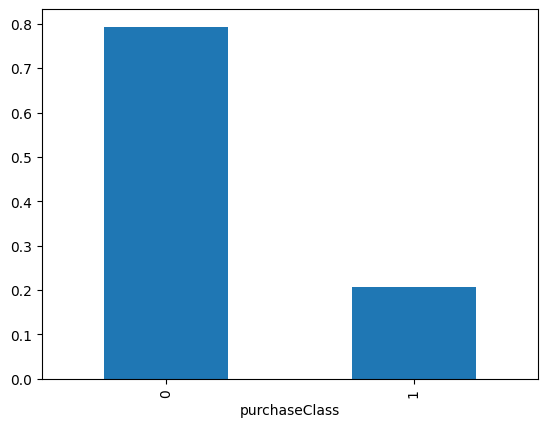

In [9]:
df['purchaseClass'] = (df['purchaseValue'] > 0).astype(int)
df['purchaseClass'].value_counts(normalize=True).plot(kind='bar')

Insights:

* Shows how imbalanced the purchase event is.
* Good for classifier model setup.

In [10]:
y_train.describe()

count    1.160230e+05
mean     2.656393e+07
std      2.051825e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.312950e+10
Name: purchaseValue, dtype: float64

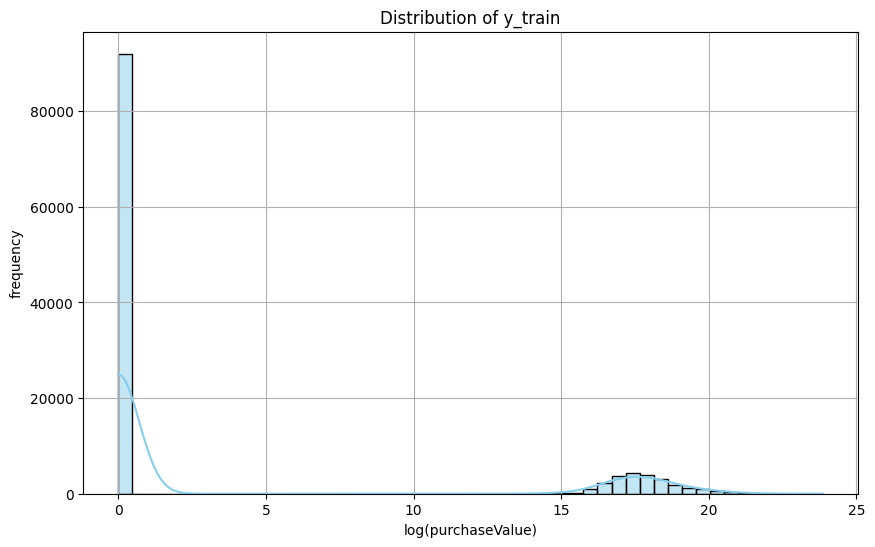

In [11]:
plt.figure(figsize = (10,6))
sns.histplot(np.log1p(y_train), bins = 50, kde = True, color = 'skyblue', edgecolor = 'black')

plt.title('Distribution of y_train', fontsize = 12)
plt.xlabel('log(purchaseValue)')
plt.ylabel('frequency')
plt.grid(True)
plt.show()

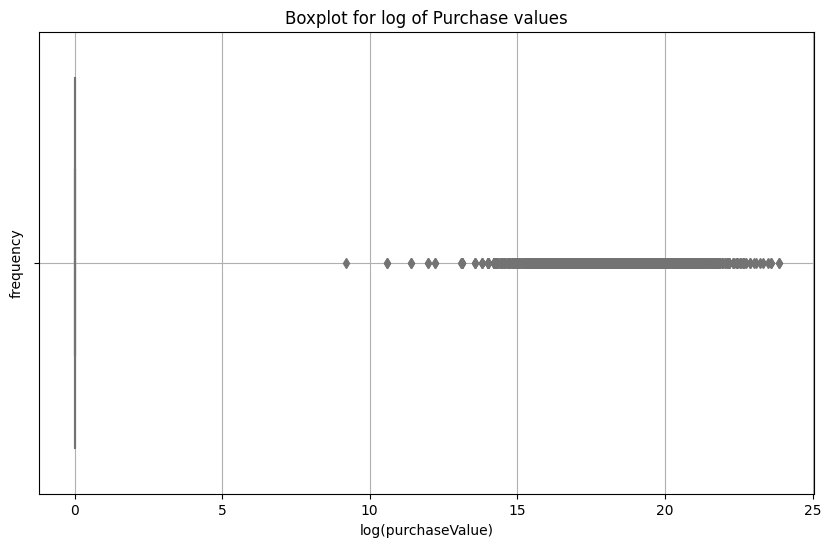

In [12]:
# Detecting outliers through boxplot

plt.figure(figsize = (10,6))
sns.boxplot(x = np.log1p(y_train), color = 'lightgreen')
plt.title('Boxplot for log of Purchase values')
plt.xlabel('log(purchaseValue)')
plt.ylabel('frequency')
plt.grid(True)
plt.show()

y_train is heavily skewed and has got lot of outliers potentially signalling some huge purchases, While most of the purchases are zero signalling most of the times customers visit a page online and do not end up buying anything

But we cannot remove outliers in this case, as outliers refer to large purchases made by customers, and we are going to miss lot of important information doing that

* Majority of Values Around 0 (Spike at Left)There's a huge spike at y_train ≈ 0 which means most users did not make a purchase.These are likely zeros or near-zero values, representing non-buyers.
  
* There's a secondary cluster around y_train ≈ 15–22, forming a bell-shaped (roughly normal) distribution. These are the actual purchase values from users who did buy, after applying log transformation.

* This is a case of Imbalanced Regression Problem with a zero-inflated target

In [13]:
X_train.describe()

,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
count,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,4281.000000,116015.000000,116023.0,47148.0,1.160230e+05,116023.000000,1.160230e+05,80518.0
mean,61094.356231,0.037019,2.691311,1.0,1.493429e+09,1.019622,8.412352,8.0,1.0,2.016860e+07,10.607371,1.493429e+09,1.0
std,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.174517,14.344937,0.0,0.0,6.182322e+03,19.629576,1.528798e+07,0.0
min,0.000000,0.000000,1.000000,1.0,1.470035e+09,1.000000,1.000000,8.0,1.0,2.016080e+07,1.000000,1.470035e+09,1.0
25%,30603.500000,0.000000,1.000000,1.0,1.480066e+09,1.000000,1.000000,8.0,1.0,2.016112e+07,1.000000,1.480066e+09,1.0
50%,61014.000000,0.000000,1.000000,1.0,1.491646e+09,1.000000,2.000000,8.0,1.0,2.017041e+07,2.000000,1.491646e+09,1.0
75%,91616.500000,0.000000,2.000000,1.0,1.505079e+09,1.000000,10.000000,8.0,1.0,2.017091e+07,12.000000,1.505079e+09,1.0
max,122276.000000,1.000000,447.000000,1.0,1.525157e+09,5.000000,469.000000,8.0,1.0,2.018043e+07,500.000000,1.525157e+09,1.0


In [14]:
for column in X_train.columns:
    unique_values = X_train[column].unique()
    print('column: ', column)
    print('unique values', (len(unique_values), unique_values))
    print('.' * 120)

column:  trafficSource.isTrueDirect
unique values (2, array([nan, True], dtype=object))
........................................................................................................................
column:  browser
unique values (34, array(['Edge', 'Chrome', 'Internet Explorer', 'Safari', 'Android Webview',
       'Firefox', 'Opera', 'Opera Mini', 'UC Browser', 'Nintendo Browser',
       'Safari (in-app)', 'Iron', 'Samsung Internet', 'YaBrowser',
       'Android Browser', 'MRCHROME', 'Coc Coc',
       'Mozilla Compatible Agent', 'Amazon Silk', 'Maxthon', 'BlackBerry',
       'Seznam', 'Nokia Browser', 'M5', 'Puffin', 'Mozilla',
       'LYF_LS_4002_12', 'MQQBrowser', 'Browser', 'osee2unifiedRelease',
       '(not set)',
       ';__CT_JOB_ID__:85da5736-a78e-45a9-837e-f5a53e5cd725;',
       'Playstation Vita Browser', 'no-ua'], dtype=object))
........................................................................................................................
column:  device.

In [15]:
# Analysis of userID-wise purchases to undersatnd user behaviour

In [16]:
user_purchase_stats = df.groupby('userId')['purchaseValue'].agg(
    total_purchase = 'sum',
    avg_puchase = 'mean',
    Total_count= 'count',
    non_zero_purchase_count = lambda x: (x > 0).sum()
).reset_index()

top_users = user_purchase_stats.sort_values(by = 'total_purchase', ascending = False).head(10)

print('Top 10 users by total purchase value \n', top_users)

Top 10 users by total purchase value 
        userId  total_purchase   avg_puchase  Total_count  \
28542   34711    1.933081e+11  3.068383e+09           63   
95254  115873    1.720260e+10  1.911400e+09            9   
61249   74460    1.602375e+10  1.602375e+10            1   
55558   67566    1.528518e+10  5.661178e+08           27   
92374  112354    1.510092e+10  1.006728e+09           15   
78124   95018    1.399300e+10  6.996500e+09            2   
2385     2915    1.329590e+10  4.431967e+09            3   
91841  111708    1.294478e+10  8.629853e+08           15   
91815  111675    1.267717e+10  1.584646e+09            8   
27187   33052    1.178085e+10  1.070986e+09           11   

       non_zero_purchase_count  
28542                       34  
95254                        8  
61249                        1  
55558                       27  
92374                       15  
78124                        2  
2385                         3  
91841                       15  
918

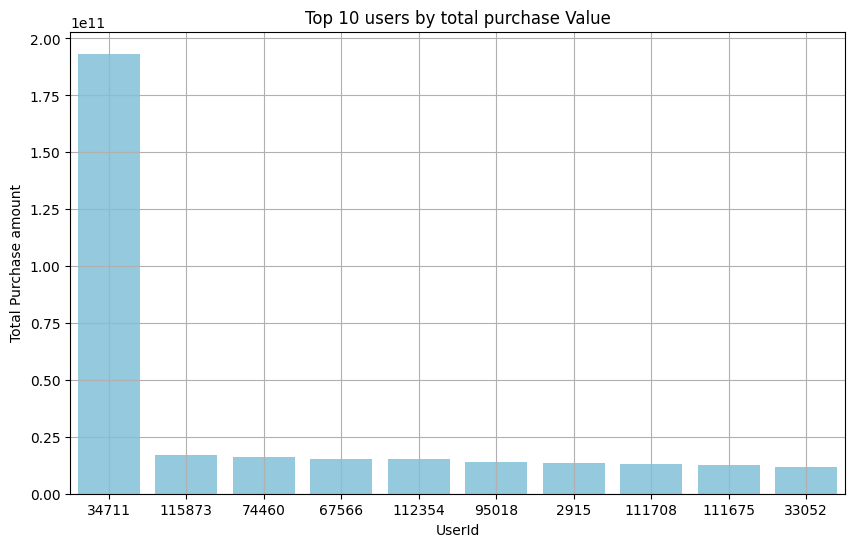

In [17]:
# Visualize top10 users
order = top_users['userId'].tolist()
plt.figure(figsize = (10,6))
sns.barplot(data = top_users, x = 'userId', y = 'total_purchase', color = 'skyblue', order=order)
            
# simply passing sorted values to graph is not working as seaborn still takes userID  original order only
plt.title('Top 10 users by total purchase Value')
plt.xlabel('UserId')
plt.ylabel('Total Purchase amount')
plt.grid(True)
plt.show()

**Insights:**


* User ID 34711 dominates heavily: Their total purchase is nearly ₹200 billion (2×10¹¹), which is orders of magnitude more than any other user.

* This is a potential outlier and could be either:

    1. A data quality issue (e.g., a wrong value or data leakage)
    2. A VIP user with bulk purchases (e.g., enterprise account)

* Rest of the users are in a similar, much lower range:

* Their total purchases are in the range of ₹10 billion to ₹20 billion.

* These users seem relatively normal and comparable to each other.

In [18]:
# Analyzing user 34711
user_34711 = df[df['userId'] == 34711]

# Check the number of purchases
print("Number of Total transaction including zero purchases:", user_34711.shape[0])

# Check max, mean and total purchases
print("Max purchase:", user_34711['purchaseValue'].max())
print("Mean purchase:", user_34711['purchaseValue'].mean())
print("Total purchase:", user_34711['purchaseValue'].sum())

Number of Total transaction including zero purchases: 63
Max purchase: 23129500000.0
Mean purchase: 3068383015.873016
Total purchase: 193308130000.0


**Insight:**

* As  there are many rows of the purchases made by 34711, user consistently makes very high-value transactions., this is a real heavy spender, not a data glitch

# Date Feature, Categorical Variable Exploration - Analysis of type of data that these features hold

**Date features:** Thereare two features associated with this Date and sessionstart Sessionstart has more information like hour (time) along with Date, year, month #So we could safely drop 'Date' feature

column: **trafficSource.isTrueDirect** unique values (2, array([nan, True], dtype=object))

**Browser** has 34 unique values with lots of spelling error and redundancy which will be taken care of later in the code

**GeoCluster** is demographic feature with 5 unique values 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_1'

**userId** has unique 100499 values indiating most users have only 1 session/row, and Some users may have more than one session (returning users), but this is not the majority.

**SessionNumber** has 230 unique values indicating level of engagement

**Os** has 18 unique values with lots of spelling error and redundancy which will be taken care of later in the code

**TrafficSource.medium** has 7 unique values 'referral', '(none)', 'organic', 'affiliate', 'cpc', 'cpm', '(not set)'

**DeviceType** has 3 unique values 'desktop', 'mobile', 'tablet' indicating which kind of device is used for browsing

**UserChannel** has 8 unique values 'Social', 'Direct', 'Organic Search', 'Referral', 'Affiliates', 'Paid Search', 'Display', '(Other)

**SessionStart** has unique 107388 values, it is a timestamp column, from which new features can be extracted like hour, day, konth , year etc.

**Target Variable**: purchaseValue: indicating purchase amount of each interaction, with mostly zeroes and some very high purcahse values

# Criteria for dropping columns
1. Single value in entire column
2. No value in entire column
3. if more than 95% data is not available

In [19]:
single_value_or_unavailable_cols = []

for col in X_train.columns:
    unique_vals = X_train[col].dropna().unique()
    if len(unique_vals) == 1 or len(unique_vals) == 0:
        single_value_or_unavailable_cols.append(col)

print("Columns with only one value or only 'not available in demoset':")
print(single_value_or_unavailable_cols)

Columns with only one value or only 'not available in demoset':
['trafficSource.isTrueDirect', 'device.screenResolution', 'screenSize', 'device.mobileDeviceBranding', 'device.mobileInputSelector', 'device.mobileDeviceMarketingName', 'device.operatingSystemVersion', 'device.flashVersion', 'totals.visits', 'geoNetwork.networkLocation', 'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor', 'device.browserSize', 'socialEngagementType', 'locationZone', 'device.mobileDeviceModel', 'totals.bounces', 'device.language', 'device.browserVersion', 'device.screenColors', 'new_visits']


In [20]:
# Define missing-like values (all lowercase for comparison)
missing_values = {'', 'not set', 'not available', 'not provided', '(not set)', '(not available)', '(not provided)'}

threshold = 0.95

mostly_missing_cols = []


for col in X_train.columns:
    col_values = X_train[col].astype(str).str.strip().str.lower()
    missing_mask = col_values.isin(missing_values) | X_train[col].isna()
    missing_ratio = missing_mask.mean()
    if missing_ratio > threshold:
        mostly_missing_cols.append(col)

print("Columns with more than 95% data as not available or not provided or blanks \n", mostly_missing_cols)

Columns with more than 95% data as not available or not provided or blanks 
 ['trafficSource.adContent', 'trafficSource.keyword', 'trafficSource.adwordsClickInfo.slot', 'trafficSource.campaign', 'trafficSource.adwordsClickInfo.isVideoAd', 'trafficSource.adwordsClickInfo.adNetworkType', 'trafficSource.adwordsClickInfo.page']


**As we can see there are many columns that donot have any value - They just have 'not avaialble in demo dataset' Some columns like 'screenSize', 'socialEngagementType' have just one unique value in the entire column, they are not going to add any information to the model

lets drop them now only to avoid clutter**

Many columns are such that they have more than 95% data as missing, we will drop them as well

In [21]:
drop_cols = [
    'trafficSource.adContent', 'trafficSource.adwordsClickInfo.slot',
    'trafficSource.adwordsClickInfo.adNetworkType', 'trafficSource.adwordsClickInfo.page',
    'trafficSource.adwordsClickInfo.isVideoAd', 'trafficSource.referralPath',
    'trafficSource.keyword', 'sessionId', 'userId', 'device.browserVersion',
    'device.flashVersion', 'device.screenResolution', 'device.browserSize',
    'device.screenColors', 'screenSize', 'device.mobileDeviceBranding', 'device.mobileInputSelector',
    'trafficSource.campaign', 'device.mobileDeviceMarketingName', 'device.operatingSystemVersion', 
    'totals.visits', 'geoNetwork.networkLocation', 'trafficSource.adwordsClickInfo.isVideoAd',
    'browserMajor', 'device.browserSize', 'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
    'trafficSource.adwordsClickInfo.page', 'locationZone', 'device.mobileDeviceModel', 'device.language',
    'device.browserVersion']


X_train.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

# Check missing value/ null value

In [22]:
# Checking missing values in columns

X_train.isnull().sum()


trafficSource.isTrueDirect    73133
browser                           0
geoCluster                        0
geoNetwork.networkDomain          0
gclIdPresent                      0
sessionNumber                     0
geoNetwork.region                 0
trafficSource                     0
os                                0
geoNetwork.subContinent           0
trafficSource.medium              0
locationCountry                   0
geoNetwork.city                   0
geoNetwork.metro                  0
pageViews                         8
totals.bounces                68875
date                              0
deviceType                        0
userChannel                       0
totalHits                         0
sessionStart                      0
geoNetwork.continent              0
device.isMobile                   0
new_visits                    35505
dtype: int64

In [23]:
# Fill missing numeric values
X_train['new_visits'].fillna(0, inplace=True)
X_train['trafficSource.isTrueDirect'].fillna(0, inplace=True)
X_train['totals.bounces'].fillna(0, inplace=True)
X_train['pageViews'].fillna(0, inplace=True)

X_test['new_visits'].fillna(0, inplace=True)
X_test['trafficSource.isTrueDirect'].fillna(0, inplace=True)
X_test['totals.bounces'].fillna(0, inplace=True)
X_test['pageViews'].fillna(0, inplace=True)



# # Fill missing categorical values
cat_cols = X_train.select_dtypes(include='object').columns
X_train[cat_cols] = X_train[cat_cols].fillna("unknown")


cat_cols_test = X_test.select_dtypes(include='object').columns
X_test[cat_cols_test] = X_test[cat_cols_test].fillna("unknown")

# No null value remains after this
# dropping geoNetwork.continent column , keeping geoNetwork.subContinent
# as it is more granular and keeping both columns will increase redundancy

X_train.drop('geoNetwork.continent', inplace=True, axis = 1)
X_test.drop('geoNetwork.continent', inplace=True, axis = 1)


# Clean column values first before frequency encoding

In [24]:

X_train['trafficSource.isTrueDirect'] = X_train['trafficSource.isTrueDirect'].replace(True, 1)

X_test['trafficSource.isTrueDirect'] = X_test['trafficSource.isTrueDirect'].replace(True, 1)

X_train['device.isMobile'] = X_train['device.isMobile'].replace(True, 1)
X_train['device.isMobile'] = X_train['device.isMobile'].replace(False, 0)

X_test['device.isMobile'] = X_test['device.isMobile'].replace(True, 1)
X_test['device.isMobile'] = X_test['device.isMobile'].replace(False, 0)
# replace incorrect spellings etc - cleaning column - 'browser'

X_train['browser'] = X_train['browser'].replace("M5", "Maxthon")
X_train['browser'] = X_train['browser'].replace("Mozilla Compatible Agent", "Firefox")
X_train['browser'] = X_train['browser'].replace("Opera Mini", "Opera")
X_train['browser'] = X_train['browser'].replace("Safari (in-app)", "Safari")
X_train['browser'] = X_train['browser'].replace("MRCHROME", "Chrome")
X_train['browser'] = X_train['browser'].replace("Mozilla", "Firefox")



X_test['browser'] = X_test['browser'].replace("M5", "Maxthon")
X_test['browser'] = X_test['browser'].replace("Mozilla Compatible Agent", "Firefox")
X_test['browser'] = X_test['browser'].replace("Opera Mini", "Opera")
X_test['browser'] = X_test['browser'].replace("Safari (in-app)", "Safari")
X_test['browser'] = X_test['browser'].replace("MRCHROME", "Chrome")
X_test['browser'] = X_test['browser'].replace("Mozilla", "Firefox")
# replace incorrect spellings etc - cleaning column - 'os'

X_train.loc[X_train['os'].str.contains('Windows'), 'os'] = 'Windows'
X_train.loc[X_train['os'].str.contains('Nintendo'), 'os'] = 'Nintendo'

X_train.loc[X_train['os'].str.contains('Windows'), 'os'] = 'Windows'
X_train.loc[X_train['os'].str.contains('Nintendo'), 'os'] = 'Nintendo'
# replace incorrect spellings etc - cleaning column - 'trafficSource'

X_train.loc[X_train['trafficSource'].str.contains('google'), 'trafficSource'] = 'google'
X_train.loc[X_train['trafficSource'].str.contains('yahoo'), 'trafficSource'] = 'yahoo'
X_train.loc[X_train['trafficSource'].str.contains('youtube'), 'trafficSource'] = 'youtube'

X_test.loc[X_test['trafficSource'].str.contains('google'), 'trafficSource'] = 'google'
X_test.loc[X_test['trafficSource'].str.contains('yahoo'), 'trafficSource'] = 'yahoo'
X_test.loc[X_test['trafficSource'].str.contains('youtube'), 'trafficSource'] = 'youtube'

# Frequency encoding categorical columns

In [25]:
# Frequency encoding for all the columns

def frequency_encode(df_train, df_test, columns):
    for col in columns:
        freq = df_train[col].value_counts(normalize=True)
        df_train[col + "_freq"] = df_train[col].map(freq)
        df_test[col + "_freq"] = df_test[col].map(freq)

        #Fill unseen categories in test with 0 (very rare)
        df_test[col + "_freq"] = df_test[col + "_freq"].fillna(0)

    df_train.drop(columns=columns, inplace=True)
    df_test.drop(columns=columns, inplace=True)

    return df_train, df_test
categorical_cols = [
    "browser",
    "geoCluster",
    "geoNetwork.networkDomain",
    "geoNetwork.region",
    "trafficSource",
    "os",
    "geoNetwork.subContinent",
    "trafficSource.medium",
    "locationCountry",
    "geoNetwork.city",
    "geoNetwork.metro",
    "deviceType",
    "userChannel"
]

# Apply frequency encoding
X_train_encoded, X_test_encoded = frequency_encode(X_train.copy(), X_test.copy(), categorical_cols)

# Extracting Date, month, year, day, hour from sessionstart column

In [26]:
from datetime import datetime, date, time

X_train_encoded['sessionStart_dt'] = pd.to_datetime(X_train_encoded['sessionStart'], unit='s')

# Extract features
X_train_encoded['session_year'] = X_train_encoded['sessionStart_dt'].dt.year
X_train_encoded['session_month'] = X_train_encoded['sessionStart_dt'].dt.month
X_train_encoded['session_day'] = X_train_encoded['sessionStart_dt'].dt.day
X_train_encoded['session_weekday'] = X_train_encoded['sessionStart_dt'].dt.weekday
X_train_encoded['session_hour'] = X_train_encoded['sessionStart_dt'].dt.hour
X_train_encoded['session_quarter'] = X_train_encoded['sessionStart_dt'].dt.quarter

X_train_encoded['session_week'] = X_train_encoded['sessionStart_dt'].dt.isocalendar().week



X_test_encoded['sessionStart_dt'] = pd.to_datetime(X_test_encoded['sessionStart'], unit='s')

# Extract features
X_test_encoded['session_year'] = X_test_encoded['sessionStart_dt'].dt.year
X_test_encoded['session_month'] = X_test_encoded['sessionStart_dt'].dt.month
X_test_encoded['session_day'] = X_test_encoded['sessionStart_dt'].dt.day
X_test_encoded['session_weekday'] = X_test_encoded['sessionStart_dt'].dt.weekday
X_test_encoded['session_hour'] = X_test_encoded['sessionStart_dt'].dt.hour
X_test_encoded['session_quarter'] = X_test_encoded['sessionStart_dt'].dt.quarter
X_test_encoded['session_week'] = X_test_encoded['sessionStart_dt'].dt.isocalendar().week

# Define function to categorize hours of the day into morning, afternoon, evening and night

In [27]:
def session_period(hour):
    if 5 <= hour <= 11:
        return 'morning'
    elif 12 <= hour <= 16:
        return 'afternoon'
    elif 17 <= hour <= 21:
        return 'evening'
    else:
        return 'night'

In [28]:
X_train_encoded['session_period'] = X_train_encoded['session_hour'].apply(session_period)
X_test_encoded['session_period'] = X_test_encoded['session_hour'].apply(session_period)

# Plot histogram of Day Of week column

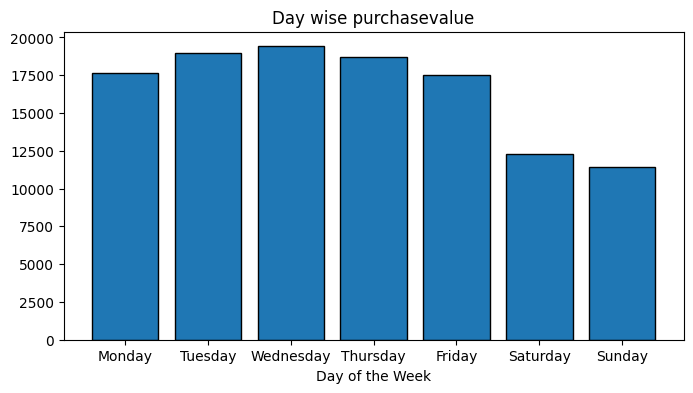

In [29]:
plt.figure(figsize=(8,4))
plt.hist(X_train_encoded['session_weekday'], bins=7, range=[0, 7], align='left', rwidth=0.8,edgecolor='black')
plt.title('Day wise purchasevalue')
plt.xlabel('Day of the Week')
plt.xticks(range(7), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

**Insights:**

* Peak Purchase Days: Wednesday and Tuesday have the highest total purchase values, followed closely by Thursday.
* Saturday and Sunday have the lowest values — significantly lower than weekdays.
* Most user purchases occur on weekdays, likely during work or routine hours.
* Weekends are less active, possibly due to reduced online time or being out of routine

# Bar Plot for Time Of Day column

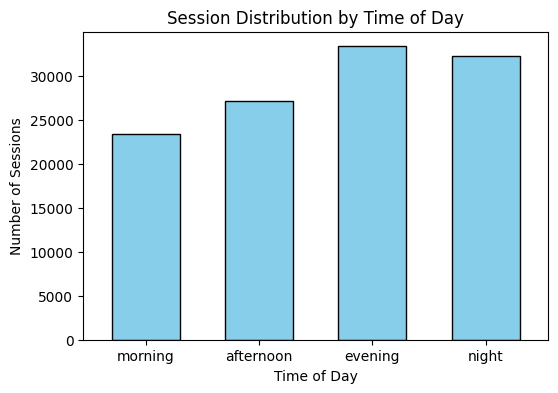

In [30]:
plt.figure(figsize=(6,4))
X_train_encoded['session_period'].value_counts().loc[['morning', 'afternoon', 'evening', 'night']].plot(
    kind='bar',
    color='skyblue',
    edgecolor='black',
    width=0.6
)
plt.title('Session Distribution by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=0)
plt.show()

**Insights:**

* Users are more likely to purchase late in the day, potentially when they're free or browsing recreationally.

* Time-based personalization or marketing (like push notifications) might be most effective during the Night window.

# Plot histogram of hour column

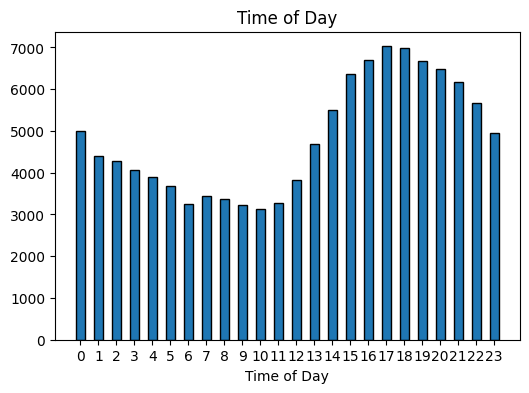

In [31]:
plt.figure(figsize=(6,4))
plt.hist(X_train_encoded['session_hour'], bins=24, range=[0, 24], align='left', rwidth=0.5,edgecolor='black')
plt.title('Time of Day')
plt.xlabel('Time of Day')
plt.xticks(range(24))
plt.show()

**Insights:**

* Key activity window: 1 PM to 9 PM — where engagement is highest.

* Lowest engagement: Early morning hours (3 AM to 11 AM).

# Detecting multicolinearity among features

In [32]:
X_train_encoded.drop('session_period', axis = 1, inplace = True)
X_test_encoded.drop('session_period', axis = 1, inplace = True)
# Detect High Collinearity Between Features
corr_matrix = X_train_encoded.corr()

# Create a mask to ignore self-correlations and duplicates (lower triangle)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = corr_matrix.where(mask)

# Find high positive or negative correlations
threshold = 0.8  # you can adjust this
high_corr = corr_pairs.stack().reset_index()
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'].abs() > threshold]

# Sort by absolute correlation value
high_corr = high_corr.sort_values(by='Correlation', ascending=False)

print("Highly correlated feature pairs:")
print(high_corr)

Highly correlated feature pairs:
                        Feature_1              Feature_2  Correlation
204                  sessionStart        sessionStart_dt     1.000000
158                          date           session_year     0.998695
454                 session_month           session_week     0.991622
89                      pageViews              totalHits     0.986250
317        geoNetwork.region_freq   geoNetwork.city_freq     0.983989
453                 session_month        session_quarter     0.974458
399          geoNetwork.city_freq  geoNetwork.metro_freq     0.967860
464               session_quarter           session_week     0.967590
318        geoNetwork.region_freq  geoNetwork.metro_freq     0.949329
361  geoNetwork.subContinent_freq   locationCountry_freq     0.947383
141                          date           sessionStart     0.912567
157                          date        sessionStart_dt     0.912567
205                  sessionStart           session_year 

In [33]:
# can drop either of totalhits or pageviews as they are correlated with each other too
# Dropping few more columns as they might have been responsible for low model scores
# metro has too many 'not set' values around 20k, totalhits broader than pageviews, country is more granular than subcontinent

# it's generated during paid ad clicks, Since trafficSource.medium has multiple categories (not just "cpc"),
# it carries more comprehensive information than gclIdPresent, which is just a binary indicator.
# Have extracted information from date already

In [34]:
drop_cols = ["sessionStart", "sessionStart_dt", 'date',          
    "session_quarter",
    "session_year" ,
    "totalHits",
    "geoNetwork.region_freq",
    "geoNetwork.metro_freq",
    "geoNetwork.subContinent_freq",
    "deviceType_freq"
       ]


X_train_encoded.drop(columns=drop_cols, inplace=True)
X_test_encoded.drop(columns=drop_cols, inplace=True)

In [35]:
print('shape of X_train_encoded', X_train_encoded.shape)
print('shape of X_test_encoded', X_test_encoded.shape)

shape of X_train_encoded (116023, 21)
shape of X_test_encoded (29006, 21)


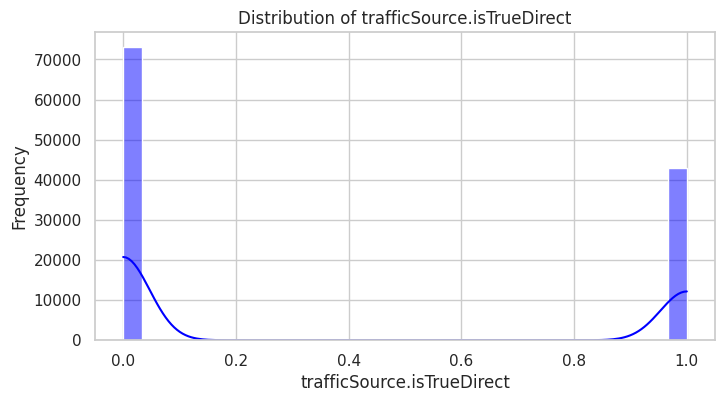

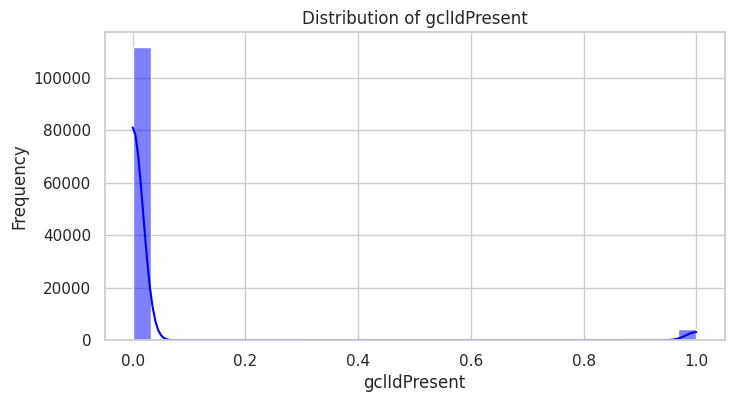

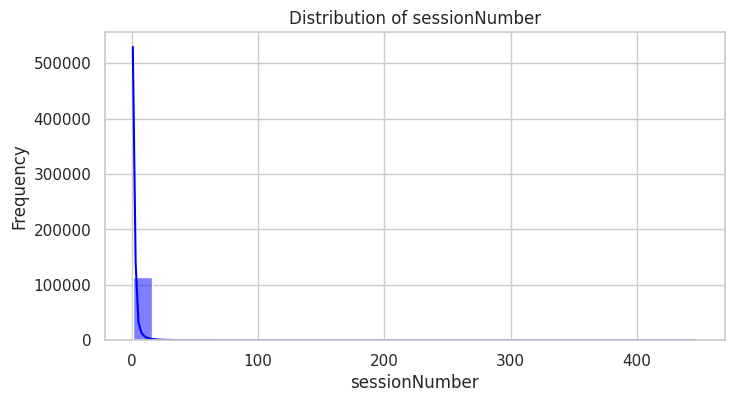

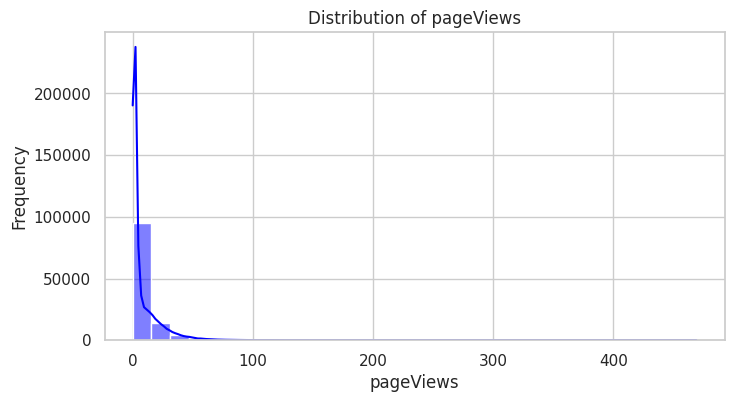

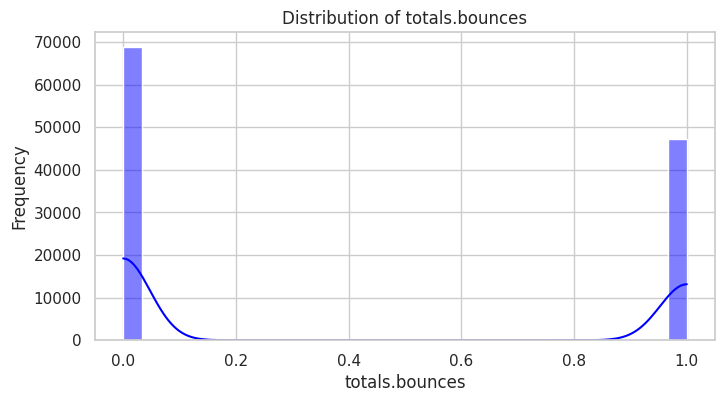

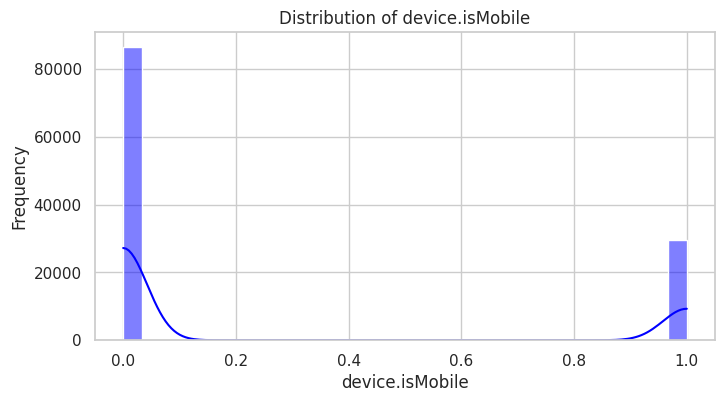

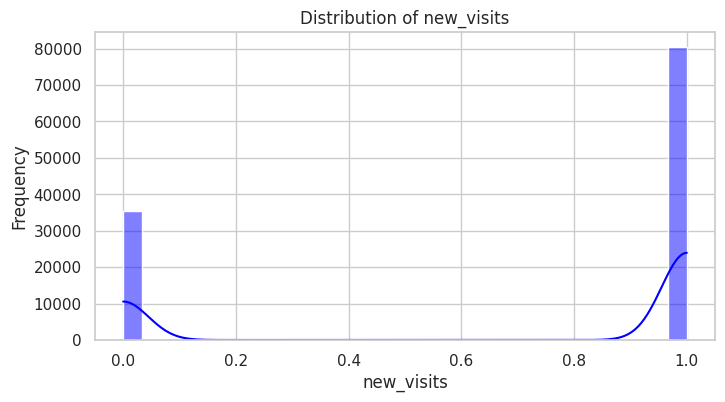

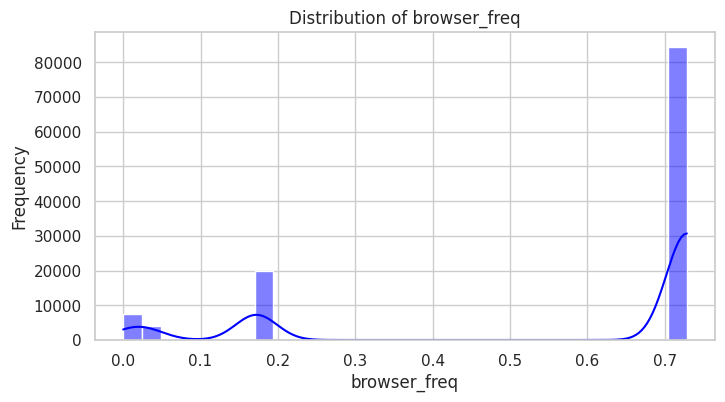

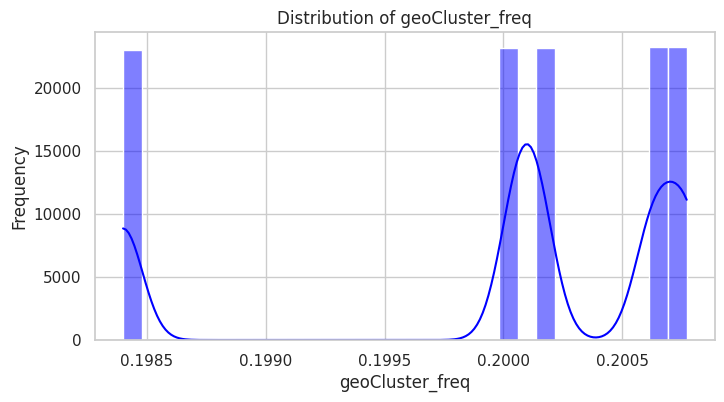

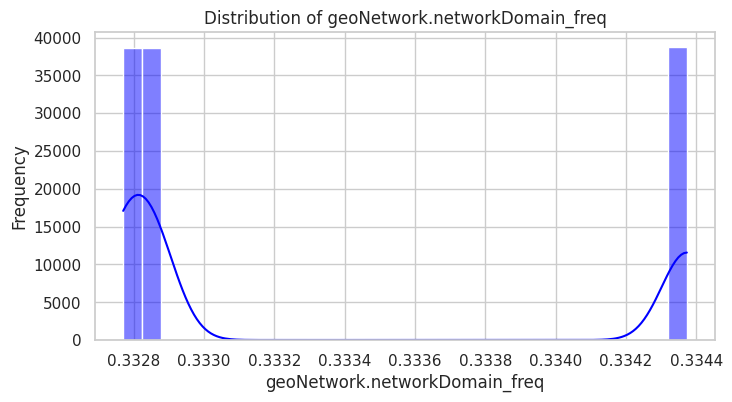

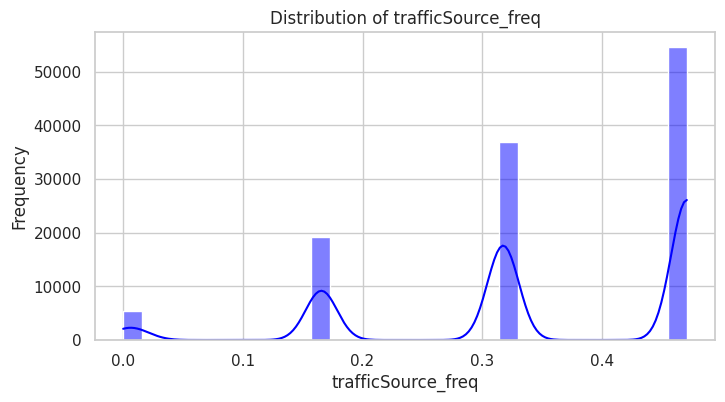

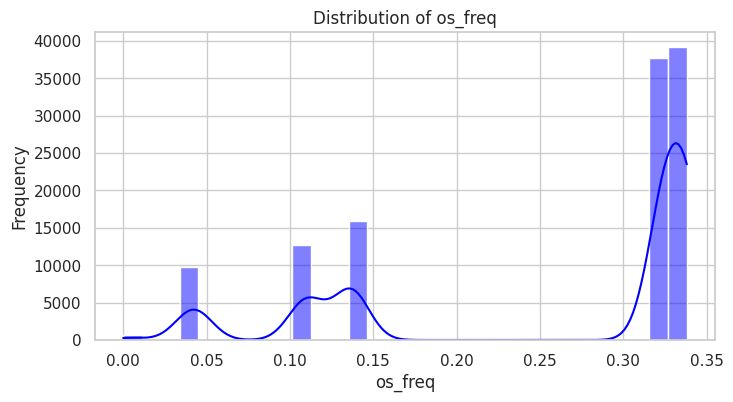

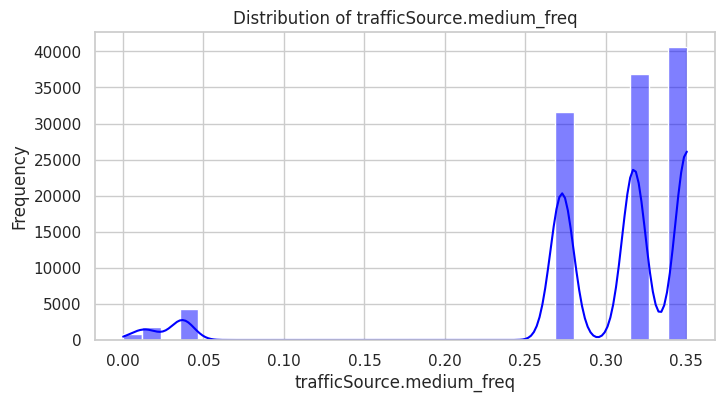

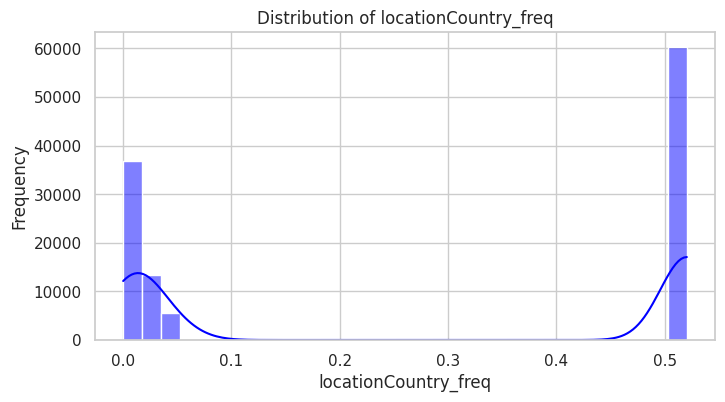

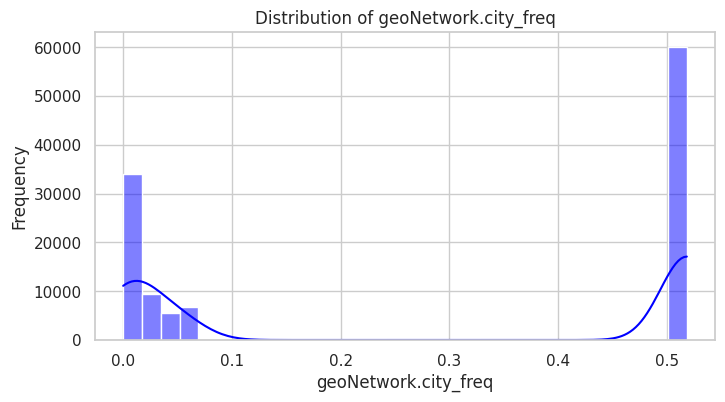

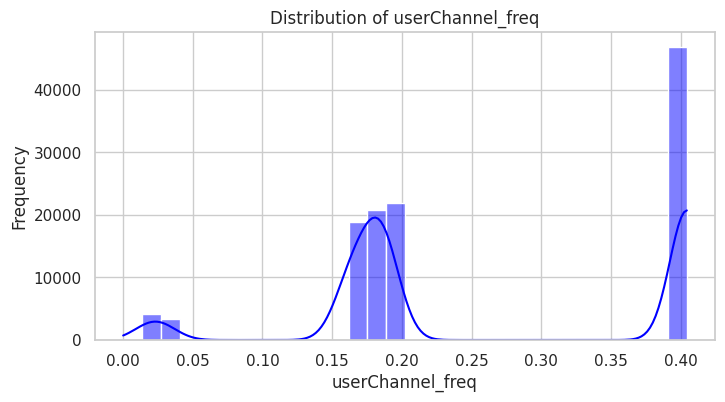

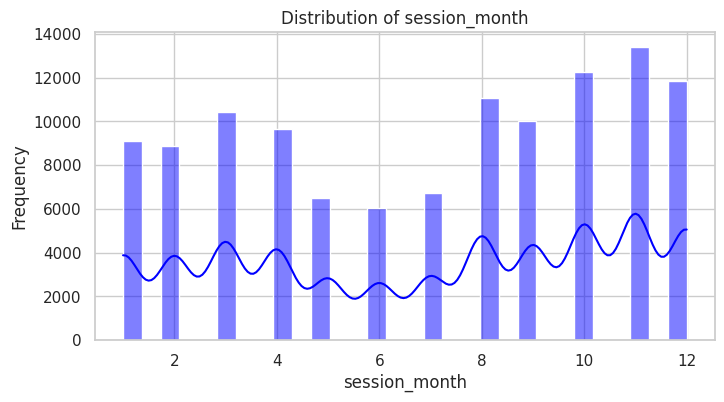

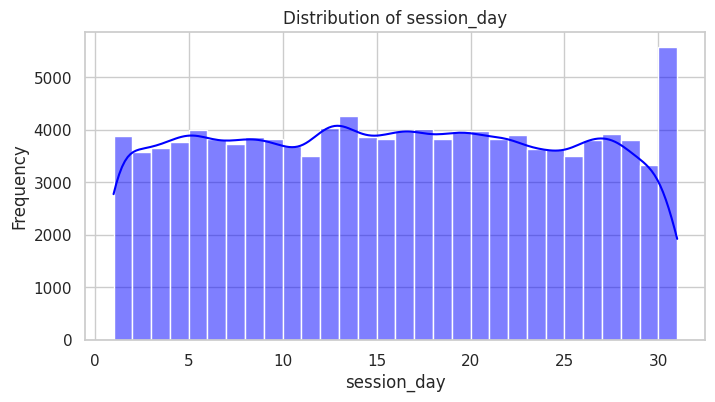

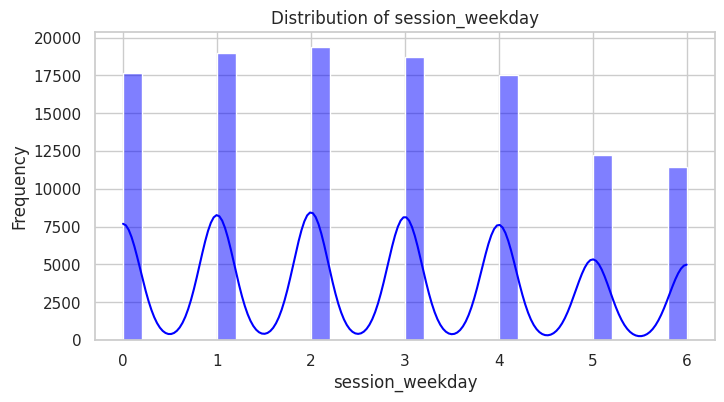

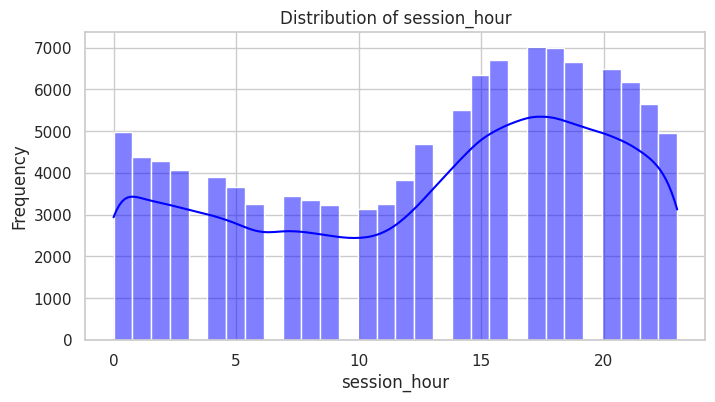

In [36]:
# After successfully extracting some useful features

# lets check the distribution of int/float type varibales

sns.set(style="whitegrid")

numerical_features = X_train_encoded.select_dtypes(include=['int64', 'float64', 'int32']).columns

for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train_encoded[feature], kde=True, bins=30, color="blue")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [37]:
# Distribution of features is such that most of the values are zero
# These graphs represent highly imbalanced distribution

# most of the browsing / page visits are made on 30th , that is the last day of month, this is consistent with general trned
# of less work on  last day of month

# Session_hour reveals most of the browsing is done in evening from 2 to 4 pm

#session- month shows that lasts months from October to December shows more browsing and is potentially
# linked to higher buying chances due to festive seasons  like thanksgiving, christmas etc

In [38]:
# Aligning columns of train and test data set
X_train_aligned, X_test_aligned = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Correlation of features with purchaseValue - Target

pageViews                     0.248456
sessionNumber                 0.230585
new_visits                   -0.123070
locationCountry_freq          0.110064
totals.bounces               -0.107116
trafficSource.isTrueDirect    0.099879
device.isMobile              -0.064042
userChannel_freq             -0.044899
browser_freq                  0.041845
session_hour                  0.038017
os_freq                       0.029562
session_weekday              -0.027644
geoNetwork.city_freq         -0.022233
trafficSource.medium_freq    -0.014993
session_week                 -0.009634
Name: purchaseValue, dtype: float64


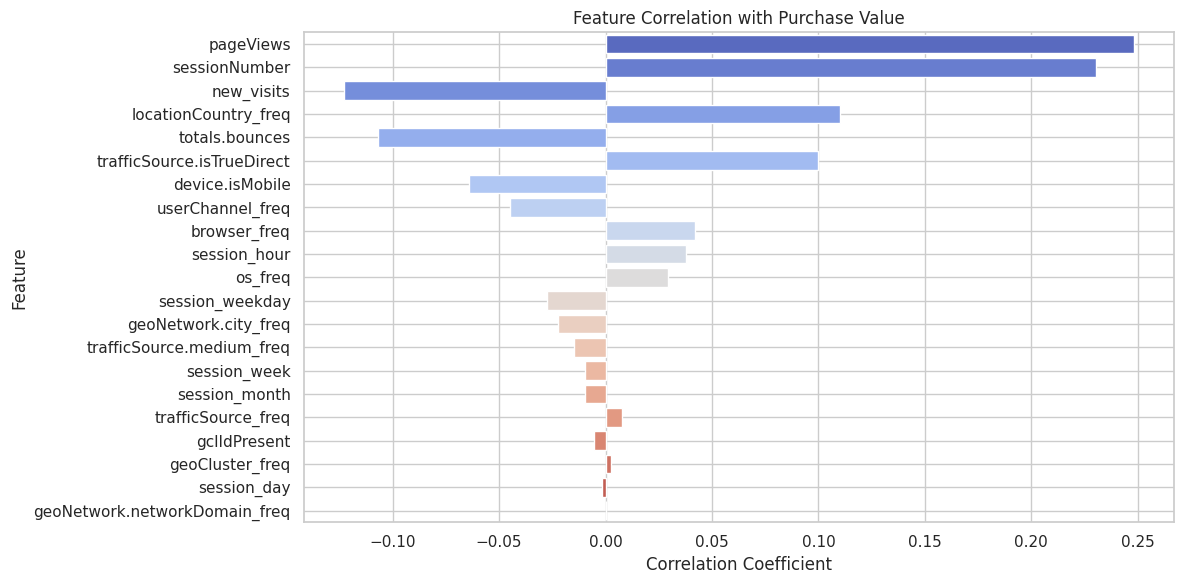

In [39]:
# Combine features and target into one DataFrame
df_corr = X_train_aligned.copy()
df_corr['purchaseValue'] = y_train

# Compute correlation matrix
correlations = df_corr.corr()

# Sort features by correlation with target
target_corr = correlations['purchaseValue'].drop('purchaseValue').sort_values(key=abs, ascending=False)

# Display top correlations
print(target_corr.head(15))

# Visualize as barplot
plt.figure(figsize=(12, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")
plt.title("Feature Correlation with Purchase Value")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()

**Insights:**

Top three - 

* **Page views**  0.25 - Users viewing more pages tend to make larger purchases. This is intuitively important.
* **Session number**  0.22 - More sessions per user = more engagement = higher purchase.
* **new_visits** -0.12 New visitors are less likely to purchase. Returning visitors are more valuable — possibly due to trust, familiarity, or retargeting.Focus on retention, remarketing, and nurturing existing users — they have higher purchase intent
* **locationCountry_freq** - 0.10 - Some countries contribute more to purchases.

In [40]:
# Aligning columns of train and test data set
X_train_aligned, X_test_aligned = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Baseline Model

In [ ]:
# Step 1: Binary Classification - Will user purchase?
y_class = (y_train > 0).astype(int)
classifier = LogisticRegression(max_iter=500, random_state=42)
classifier.fit(X_train_aligned, y_class)

# Step 2: Dummy Regressor as base model (only for positive purchase rows)
mask = y_train > 0
X_train_pos = X_train_aligned[mask]
y_train_pos = y_train[mask]

# Split positive purchases into train and validation
Xtrain, Xval, ytrain, yval = train_test_split(X_train_pos, y_train_pos, test_size=0.2, random_state=42)

# Base Regressor
base_regressor = DummyRegressor(strategy='mean')
base_regressor.fit(Xtrain, ytrain)

# Predict and evaluate
y_val_pred = base_regressor.predict(Xval)

base_model_r2score = r2_score(yval, y_val_pred)

print("Base Model R²:", r2_score(yval, y_val_pred))
print("Base Model RMSE:", mean_squared_error(yval, y_val_pred, squared=False))

# Model - 2 Random Forest Regressor

In [ ]:
# Step 1: Classifier Target
y_class = (y_train > 0).astype(int)  # Binary label: purchase vs. no purchase
classifier = LogisticRegression(max_iter=500, random_state=42)
classifier.fit(X_train_aligned, y_class)

# STEP 2: Regressor – Only on Purchased Users

mask = y_train > 0
X_train_pos = X_train_aligned[mask]
y_train_pos = y_train[mask]

# Split for validation
Xtrain, Xval, ytrain, yval = train_test_split(
    X_train_pos, y_train_pos, test_size=0.2, random_state=42
)

# 2. Define RandomForest model
regressor = RandomForestRegressor(random_state=42, n_jobs=-1)

# 3. Define hyperparameter space
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=regressor,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(Xtrain, ytrain)

best_model = random_search.best_estimator_

y_val_pred = best_model.predict(Xval)
Random_forest_regressor_r2score = r2_score(yval, y_val_pred)
rmse = np.sqrt(mean_squared_error(yval, y_val_pred))

print(f" Best Parameters: {random_search.best_params_}")
print(f" Validation R² Score: {Random_forest_regressor_r2score:.4f}")
print(f" Validation RMSE: {rmse:.2f}")

# Model - 3 HGB regressor

In [ ]:
# STEP 1: Binary Classification
y_class = (y_train > 0).astype(int)
classifier = LogisticRegression(max_iter=500, random_state=42)
classifier.fit(X_train_aligned, y_class)


# STEP 2: Regression Only for Users Who Made Purchase

mask = y_train > 0
X_pos = X_train_aligned[mask]
y_pos = y_train[mask]

Xtrain, Xval, ytrain, yval = train_test_split(X_pos, y_pos, test_size=0.2, random_state=42)

# Model
hgb_model = HistGradientBoostingRegressor(random_state=42)

# Hyperparameter space
param_dist = {
    'learning_rate': uniform(0.01, 0.2),
    'max_iter': randint(100, 500),
    'max_leaf_nodes': randint(20, 100),
    'max_depth': randint(3, 12),
    'min_samples_leaf': randint(10, 50),
    'l2_regularization': uniform(0.0, 1.0)
}

# Hyperparameter Tuning
random_search = RandomizedSearchCV(
    estimator=hgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(Xtrain, ytrain)
best_model = random_search.best_estimator_

# Evaluation
yval_pred = best_model.predict(Xval)
print(f" Best Parameters: {random_search.best_params_}")
HGB_regressor_r2score = r2_score(yval, yval_pred)
print(f" Validation R² Score: {r2_score(yval, yval_pred):.4f}")
print(f" Validation RMSE: {mean_squared_error(yval, yval_pred, squared=False):.2f}")

# Model - 4 LightGBM regressor

In [ ]:
# Step 1: Classification
y_class = (y_train > 0).astype(int)
classifier = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
classifier.fit(X_train_aligned, y_class)

# Validation split for classifier
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_train_aligned, y_class, test_size=0.2, random_state=42
)
classifier.fit(X_train_cls, y_train_cls)
y_val_cls_pred = classifier.predict(X_val_cls)

print("Confusion Matrix:\n", confusion_matrix(y_val_cls, y_val_cls_pred))
print("Classification Report:")
print(classification_report(y_val_cls, y_val_cls_pred))

# Step 2: Regressor – Only for purchasers
mask = y_train > 0
X_train_pos = X_train_aligned[mask]
y_train_pos = y_train[mask]

Xtrain, Xval, ytrain, yval = train_test_split(X_train_pos, y_train_pos, test_size=0.2, random_state=42)

regressor = LGBMRegressor(objective='regression', random_state=42, n_jobs=-1)

# Hyperparameter tuning
param_dist = {
    'n_estimators': randint(50, 150),                 
    'max_depth': randint(3, 8),                       
    'learning_rate': uniform(0.03, 0.1),               
    'num_leaves': randint(15, 50),                     
    'min_child_samples': randint(10, 30),              
    'subsample': uniform(0.7, 0.2),                    
    'colsample_bytree': uniform(0.7, 0.2),
    'reg_alpha': uniform(0.0, 0.5),               
}

# Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=regressor,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(Xtrain, ytrain)

best_model = random_search.best_estimator_
y_val_pred = best_model.predict(Xval)
lgb_regressor_r2score = r2_score(yval, y_val_pred)
rmse = np.sqrt(mean_squared_error(yval, y_val_pred))

print(f" \n Best Parameters: {random_search.best_params_}")
print(f" Validation R² Score: {lgb_regressor_r2score:.4f}")
print(f" Validation RMSE: {rmse:.2f}")

# Refit on full training
best_model.fit(X_train_aligned, y_train)

# Predict on test set
y_test_pred = best_model.predict(X_test_aligned)
y_test_pred = np.clip(y_test_pred, 0, None)

# Model - 5 XGB MODEL

In [ ]:
# 2 Step model - classification followed by regression
# Classifying purchases from non-purchases and passing classifier's result to the XGB regressor
# Step 1: Classifier Target
y_class = (y_train > 0).astype(int)
classifier = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
classifier.fit(X_train_aligned, y_class)

# Create validation split for classifier
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_train_aligned, y_class, test_size=0.2, random_state=42
)

# Re-train classifier on classifier training split
classifier.fit(X_train_cls, y_train_cls)

# Predict on validation set
y_val_cls_pred = classifier.predict(X_val_cls)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_val_cls, y_val_cls_pred)
print(" Confusion Matrix:\n", conf_matrix)

# Optional: classification report
print("\n Classification Report:")
print(classification_report(y_val_cls, y_val_cls_pred))

# STEP 2: Regressor – Only on Purchased Users

# Select only rows where purchase was made
mask = y_train > 0
X_train_pos = X_train_aligned[mask]
y_train_pos = y_train[mask]

# Split for validation
Xtrain, Xval, ytrain, yval = train_test_split(
    X_train_pos, y_train_pos, test_size=0.2, random_state=42
)

# 2. Define the model
regressor = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)


# 3. Define hyperparameter space

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0, 1.0)
}

# 4.RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=regressor,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


random_search.fit(Xtrain, ytrain)

best_model = random_search.best_estimator_

y_val_pred = best_model.predict(Xval)
XGB_regressor_r2score = r2_score(yval, y_val_pred)
rmse = np.sqrt(mean_squared_error(yval, y_val_pred))

print(f"\n Best Parameters: {random_search.best_params_}")


print(f" Validation R² Score: {XGB_regressor_r2score:.4f}")
print(f" Validation RMSE: {rmse:.2f}")
best_xgb_model = random_search.best_estimator_

# Refit on the entire training dataset
best_xgb_model.fit(X_train_aligned, y_train)

# Model - 5 Stacking Regressor

In [ ]:
# Step 1: Classifier to identify purchasers
y_class = (y_train > 0).astype(int)
classifier = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
classifier.fit(X_train_aligned, y_class)

# Optional classifier evaluation
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(X_train_aligned, y_class, test_size=0.2, random_state=42)
classifier.fit(X_train_cls, y_train_cls)
y_val_cls_pred = classifier.predict(X_val_cls)

from sklearn.metrics import confusion_matrix, classification_report
print("\n Confusion Matrix:\n", confusion_matrix(y_val_cls, y_val_cls_pred))
print("\n Classification Report:\n", classification_report(y_val_cls, y_val_cls_pred))

# Step 2: Regressor on purchasers only
mask = y_train > 0
X_train_pos = X_train_aligned[mask]
y_train_pos = y_train[mask]

Xtrain, Xval, ytrain, yval = train_test_split(X_train_pos, y_train_pos, test_size=0.2, random_state=42)

# Base Regressors
xgb = XGBRegressor(
    colsample_bytree=0.6092, learning_rate=0.1149, max_depth=9, n_estimators=269,
    reg_alpha=0.0466, reg_lambda=0.9737, subsample=0.6931, objective='reg:squarederror',
    random_state=42, n_jobs=-1
)

rf = RandomForestRegressor(
    max_depth=13, max_features='auto', min_samples_leaf=1,
    min_samples_split=2, n_estimators=170, random_state=42, n_jobs=-1
)

hgb = HistGradientBoostingRegressor(
    l2_regularization=0.9422, learning_rate=0.1226, max_depth=11,
    max_iter=445, max_leaf_nodes=72, min_samples_leaf=11, random_state=42
)

lgbm = LGBMRegressor(
    colsample_bytree=0.7239, learning_rate=0.1013, max_depth=3,
    min_child_samples=14, n_estimators=139, num_leaves=28,
    reg_alpha=0.2469, subsample=0.8045, random_state=42, n_jobs=-1
)

# Stacking Regressor
stack = StackingRegressor(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('lgbm', lgbm),
        ('hgb', hgb)
    ],
    final_estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    n_jobs=-1,
    passthrough=True
)

stack.fit(Xtrain, ytrain)
y_val_pred = stack.predict(Xval)
stacking_regressor_r2score = r2_score(yval, y_val_pred)
print("\n Validation R² Score:", stacking_regressor_r2score)
print(" Validation RMSE:", np.sqrt(mean_squared_error(yval, y_val_pred)))

# Final model on all aligned train data (only regressor)
stack.fit(X_train_aligned, y_train)
y_test_pred = stack.predict(X_test_aligned)
y_test_pred = np.clip(y_test_pred, 0, None)

# Plot the graph

In [ ]:
models = ['Baseline model', 'Random Forest Regressor', 'HGB regressor', 'LGB regressor' ,'XGB regressor', 'Stacking regressor']

Accuracy_scores = np.array([base_model_r2score, Random_forest_regressor_r2score, HGB_regressor_r2score, lgb_regressor_r2score, XGB_regressor_r2score, stacking_regressor_r2score ])

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=models, y=Accuracy_scores, marker='o', label='Model Scores')

#Plotting the cutoff line in red
cutoff=0.45
plt.axhline(y=cutoff, color='red', linestyle='--', label=f'Accuracy Cutoff ({cutoff})')

#Setting labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Model Scores')
plt.legend()
plt.xticks(rotation=60, ha='right')

#Display the plot
plt.tight_layout()
plt.show()

**Insights:**

* XGBoost Regressor is performing best among all the models, accuracy score achieved on training dataset is 0.7441

* Best Hyperparameter for Random forest regressor are  'max_depth': 13, 'max_features': 'auto', 'min_samples_leaf': 1, 
                                                     'min_samples_split': 2, 'n_estimators': 170


* Best Hyperparameter for HGB regressor are 'l2_regularization': 0.9422017556848528, 
                                          'learning_rate': 0.12265764356910785, 'max_depth': 11, 
                                          'max_iter': 445, 'max_leaf_nodes': 72, 'min_samples_leaf': 11


* Best Hyperparameter for LightGBM regressor are 'colsample_bytree': 0.7239188491876603, 'learning_rate': 0.10132447872229951,
                                                 'max_depth': 3, 'min_child_samples': 14, 'n_estimators': 139, 'num_leaves': 28,                                                        'reg_alpha': 0.24689779818219537, 'subsample': 0.8045465658763988

* Best Hyperparameter for XGB regressor are 'colsample_bytree': 0.6092249700165663, 
                                          'learning_rate': 0.11495493205167782, 'max_depth': 9, 'n_estimators': 269, 
                                          'reg_alpha': 0.04666566321361543, 'reg_lambda': 0.9737555188414592, 
                                          'subsample': 0.6931085361721216

# Prediciton using the best performing model

In [ ]:
# Predict on test data
y_test_pred = best_xgb_model.predict(X_test_aligned)

# Clipping negative predictions
y_test_pred = np.clip(y_test_pred, 0, None)

# Generate CSV file

In [ ]:
submission = pd.DataFrame({
    "id": range(len(X_test_aligned)),
    'purchaseValue': y_test_pred
})

# Step 5: Save to CSV
submission.to_csv("submission.csv", index=False)
print("✅ Submission file saved: submission.csv")

# Code Correction

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
from scipy.stats import uniform, randint
import numpy as np

# ---- Step 1: Classifier Setup ----
# Binary target for classifier
y_class = (y_train > 0).astype(int)

# Split for classifier training and validation
X_cls_train, X_cls_val, y_cls_train, y_cls_val = train_test_split(
    X_train_aligned, y_class, test_size=0.2, random_state=42
)

# Logistic Regression classifier and hyperparameter space
clf_model = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)

clf_param_grid = {
    'C': uniform(0.01, 10),
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
}

clf_search = RandomizedSearchCV(
    clf_model,
    param_distributions=clf_param_grid,
    n_iter=10,
    scoring='recall',  # or 'f1' depending on what you value more
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

clf_search.fit(X_cls_train, y_cls_train)
best_classifier = clf_search.best_estimator_

print("\nClassifier Best Params:", clf_search.best_params_)
print("\nClassifier Confusion Matrix:\n", confusion_matrix(y_cls_val, best_classifier.predict(X_cls_val)))
print("\nClassifier Report:\n", classification_report(y_cls_val, best_classifier.predict(X_cls_val)))

# ---- Step 2: Regressor Setup ----
# Get training data for regressor (true purchasers only)
mask = y_train > 0
X_reg_train_full = X_train_aligned[mask]
y_reg_train_full = y_train[mask]

# Split for regressor validation
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_train_full, y_reg_train_full, test_size=0.2, random_state=42
)

# XGBRegressor and hyperparameter space
regressor = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

reg_param_grid = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0, 1.0)
}

reg_search = RandomizedSearchCV(
    regressor,
    param_distributions=reg_param_grid,
    n_iter=30,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

reg_search.fit(X_reg_train, y_reg_train)
best_regressor = reg_search.best_estimator_

print("\nRegressor Best Params:", reg_search.best_params_)

# ---- Step 3: Connect Classifier & Regressor on Validation Set ----
# Create a validation set from the full training data
X_full_train, X_val, y_full_train, y_val = train_test_split(
    X_train_aligned, y_train, test_size=0.2, random_state=42
)

# Apply classifier to validation set
y_val_class_pred = best_classifier.predict(X_val)

# Filter predicted buyers
X_val_predicted_buyers = X_val[y_val_class_pred == 1]
y_val_true_for_predicted_buyers = y_val[y_val_class_pred == 1]

# Apply regressor only to predicted buyers
if len(X_val_predicted_buyers) > 0:
    y_val_pred = best_regressor.predict(X_val_predicted_buyers)
    r2 = r2_score(y_val_true_for_predicted_buyers, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_true_for_predicted_buyers, y_val_pred))

    print(f"\n✅ Two-Step Model Evaluation (Classifier-gated):")
    print(f"Validation R²: {r2:.4f}")
    print(f"Validation RMSE: {rmse:.2f}")
else:
    print("\n⚠️ Classifier predicted no buyers in the validation set.")


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Classifier Best Params: {'C': 0.5741157902710026, 'penalty': 'l2', 'solver': 'liblinear'}

Classifier Confusion Matrix:
 [[17290  1094]
 [  161  4660]]

Classifier Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96     18384
           1       0.81      0.97      0.88      4821

    accuracy                           0.95     23205
   macro avg       0.90      0.95      0.92     23205
weighted avg       0.95      0.95      0.95     23205

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Regressor Best Params: {'colsample_bytree': 0.6092249700165663, 'learning_rate': 0.11495493205167782, 'max_depth': 9, 'n_estimators': 269, 'reg_alpha': 0.04666566321361543, 'reg_lambda': 0.9737555188414592, 'subsample': 0.6931085361721216}

✅ Two-Step Model Evaluation (Classifier-gated):
Validation R²: 0.8070
Validation RMSE: 186625201.12


In [ ]:
# for test set

In [ ]:
#Predict buyers using the classifier
class_preds = classifier.predict(X_test)  # binary: 1 = predicted to buy, 0 = not buy

#Create an empty prediction array
final_preds = np.zeros(len(X_test))  # initialize all to 0

#Use regressor only for predicted buyers
X_test_buyers = X_test[class_preds == 1]
reg_preds = regressor.predict(X_test_buyers)

#Fill in predictions for predicted buyers only
final_preds[class_preds == 1] = reg_preds